# Analysis of simulated trajectorories

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [2]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from openberg_july2026.src2.utils0 import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *

In [3]:
ib = 'iceberg2025w'

In [35]:
#read sim
file_contain_all = [ib,]
file_contain_any = ['_']
file_notcontain = ['test','prof','vocean','next']#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/%s/*.nc"%ib)
# file_l = glob.glob("./results/%s*.nc"%ib)
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l[::-1]
print(file_l)
# file_l = [
#         './results/iceberg2026e_gebco_topaz5_windglophynrt_mainrun_1D_mainrun.nc',
#           './results/iceberg2026e_gebco_topaz5_windglophynrt_lead10_mainrun_1D_leadtime10D_mainrun_allmostfull.nc',
#         #   './results/iceberg2026e_gebco_topaz5_windglophynrt_idx30-36_debris_radius10000_n20_l50_maxdraft.nc',
#         # './results/iceberg2026e_gebco_topaz5_windglophynrt_idx30-36_lead10_debris_radius10000_lead10D__n20_l50_maxdraft.nc'
    
#          ]

['./results/iceberg2025w/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_joined_idx0-8.nc', './results/iceberg2025w/iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined.nc', './results/iceberg2025w/iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined.nc']


In [36]:
#checks
for f in file_l:
    sim=xr.open_dataset(f)
    print(f,sim.trajectory.size,sim.time.size,sim.attrs['config_drift:vertical_profile'],np.all(np.isnan(sim.lat.values)))

./results/iceberg2025w/iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_joined_idx0-8.nc 99 864 False False
./results/iceberg2025w/iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined.nc 143 1248 False False
./results/iceberg2025w/iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined.nc 143 1248 False False
./results/iceberg2025w/iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined.nc 143 1248 False False
./results/iceberg2025w/iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined.nc 143 1248 False False


In [37]:
#dicts and definitions
nono = ('ICEBERG','NEXTSIM')
legenddict_full = {k:v for k,v in legenddict_full.items() if k not in nono}
legenddict_full = {'NEXTSIMRE':{'col':'plum','alpha':1,'zo':40},**legenddict_full}
legenddict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l])
for f in legenddict:
    ll = []
    for l in legenddict_full:
        # print(f,l,ll)
        if l.lower() in f.lower(): ll = ll+[l]
    legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':legenddict_full[ll[-1]]['alpha'], 
                   'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                 # 'traj':np.arange(obs.time.size*11)
                  }
#manual adaptions
# legenddict['iceberg2018b_gebco_topaz6_topaz4_windglophyre_mainrun_joined']['col']='turquoise'
# legenddict['iceberg2018b_gebco_glorys_windglophyre_mainrun_joined']['col']='darkolivegreen'
# legenddict['iceberg2018b_gebco_topaz4_windglophyre_mainrun_joined']['col']='darkslateblue'
# legenddict['iceberg2018b_gebco_nextsimre_windglophyre_joined']['col']='plum'
legenddict 

{'iceberg2025w_gebco_topaz6_topaz5_windglophynrt_newcoefmix_joined_idx0-8': {'col': 'turquoise',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, TOPAZ5, TOPAZ6',
  'zo': 24},
 'iceberg2025w_gebco_glorys_windglophynrt_newcoefmix_joined': {'col': 'darkolivegreen',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, GLORYS',
  'zo': 20},
 'iceberg2025w_gebco_topaz4_windglophynrt_newcoefmix_joined': {'col': 'darkslateblue',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, TOPAZ4',
  'zo': 22},
 'iceberg2025w_gebco_topaz5_windglophynrt_newcoefmix_joined': {'col': 'cornflowerblue',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, TOPAZ5',
  'zo': 23},
 'iceberg2025w_gebco_glophyanfcH_glophyanfcD_windglophynrt_newcoefmix_joined': {'col': 'darkseagreen',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, GLOPHYANFCH, GLOPHYANFCD',
  'zo': 21}}

In [38]:
#read obs
fname = 'merged_obs10'#'merged_obs_iceberg2026e_1D'
with xr.open_dataset('./input/%s.nc'%fname) as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    obs_seed = obs.isel(time=(obs.seed_idx==1))

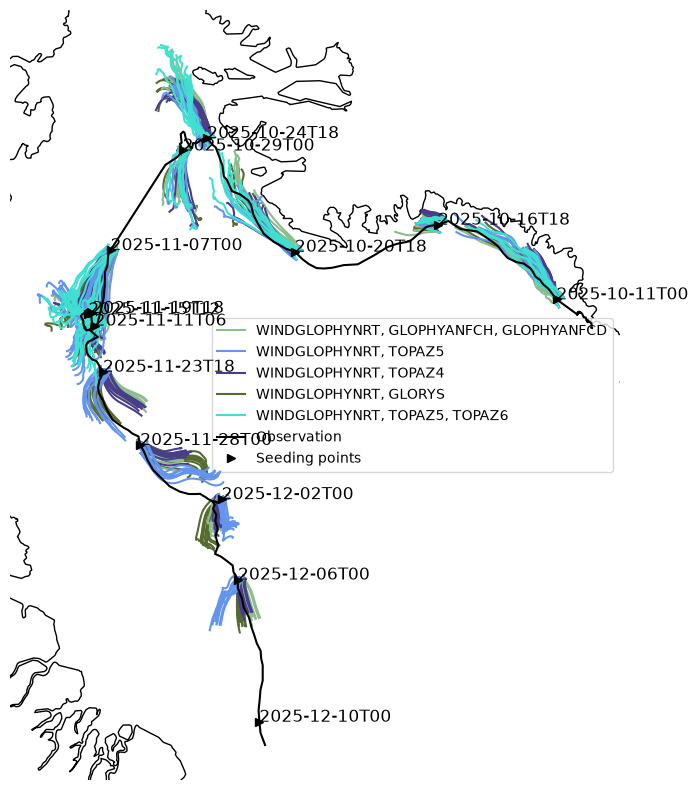

In [39]:
#very simple plot of simulations
# %pip install ipympl
# %matplotlib widget
# ib = 'iceberg2018b'
try: del apn_obs
except: pass
apn=None
# apn = {'time':dict_analysis_period[ib]['full']} #time subset by dict
# apn = {'time':slice('2026-07-02T08','2026-07-09T08')} #time subset by date
# apn = obs_seed.time.sel(time=[apn.start,apn.stop],method='nearest') #time subset by seedtime dates -part1
# apn = slice(str(apn.values[0]),str(apn.values[1])) #time subset by seedtime dates -part2
    #loop1
# apn_obs= {'time':slice(obs_seed.time.values[30],obs_seed.time.values[38])} #time subset by seed time idx
    #loop2
# apn_obs= {'time':slice(obs_seed.time.values[54],obs_seed.time.values[61])} #time subset by seed time idx
    #loop3
# apn_obs= {'time':slice(obs_seed.time.values[60],obs_seed.time.values[70])} #time subset by seed time idx



#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=float(obs.lon.mean()))})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()

# # plot obs
zo1=200
try: apn_obs
except: apn_obs=apn
# if ib in dict_analysis_period: apn_obs = {'time':dict_analysis_period[ib]['full']}
ax.plot(obs_seed['lon'].sel(apn_obs),obs_seed['lat'].sel(apn_obs),'>',transform=trans,color='k',label='Seeding points',zorder=zo1)
ax.plot(obs['lon'].sel(apn_obs),obs['lat'].sel(apn_obs),transform=trans,color='k',label='Observation',zorder=zo1)
# for d in range(obs_3day['time'].size):
for d in np.arange(obs_seed['time'].sel(apn_obs).size)[:]:
#     if d not in [1,2,3,4,5,12,15,16,17,18,19]:
        ax.text(obs_seed['lon'].sel(apn_obs)[d],obs_seed['lat'].sel(apn_obs)[d],
                obs_seed['time'].sel(apn_obs)[d].values.astype('datetime64[h]').astype(str),transform=trans,color='k',fontsize=12,zorder=zo1)


# plot sim
zo2=10
for inputdataidx, inputdata in enumerate(file_l):
    sim = xr.open_dataset(inputdata)
    inputdata = inputdata.split('/')[-1][:-3]
    # apn = {'trajectory':slice(30,37)} if 'mainrun' in inputdata else {'trajectory':slice(0,20*8)} #loop1
    # apn = {'trajectory':slice(54,60)} if 'mainrun' in inputdata else {'trajectory':slice(0,140)} #loop2
    # apn = {'trajectory':slice(60,70)} if 'mainrun' in inputdata else {'trajectory':slice(141,290)} #loop3
    if apn!=None: sim = sim.sel(apn)
    if ib in dict_traj: 
        if inputdata in dict_traj[ib]: sim = sim.sel(trajectory=dict_traj[ib][inputdata])
    # if ('arcmfcwam' in inputdata) and ('topaz' in inputdata): col1='red'
    # elif ('arcmfcwam' in inputdata) and ('glorys' in inputdata): col1='orange'
    # elif ('waverys' in inputdata) and ('topaz' in inputdata): col1='darkblue'
    # elif ('waverys' in inputdata) and ('glorys' in inputdata): col1='lightblue'
    for traj in sim.trajectory:
        ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
                color=legenddict[inputdata]['col'], #if 'prof' not in inputdata else 'red',
                label=legenddict[inputdata]['kw'] if traj==sim.trajectory[0] else '',#) if 'mainrun' not in inputdata else '',
                zorder=legenddict[inputdata]['zo'],
                alpha=legenddict[inputdata]['alpha'],
                linestyle='-' if 'mainrun' not in inputdata else ':',#) if 'debris' not in inputdata else ':',
                transform=trans)

#legend
h, l = ax.get_legend_handles_labels()
by_label = dict(zip(l, h))
ax.legend(handles=list(by_label.values())[::-1],
         labels=list(by_label.keys())[::-1],
          loc='best')
         
# plt.legend()
plt.axis('off')
# note = ''
# fig.savefig('./results/%s_map_%s.png'%(iceberg_id,note),dpi=200,transparent=True,bbox_inches='tight')
plt.show()



In [9]:
# np.datetime64(dict_analysis_period['iceberg2011w1']['full'].stop)-np.datetime64(dict_analysis_period['iceberg2011w1']['full'].start)
np.datetime64('2011-12-22')-np.datetime64('2012-02-11')

np.timedelta64(-51,'D')

In [10]:
linspace = np.linspace(0,1,11)
randcoefwa = linspace*1.25+0.25
randcoefwi = linspace*1+0.5
randcoefwa,randcoefwi

(array([0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875, 1.   , 1.125, 1.25 ,
        1.375, 1.5  ]),
 array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]))

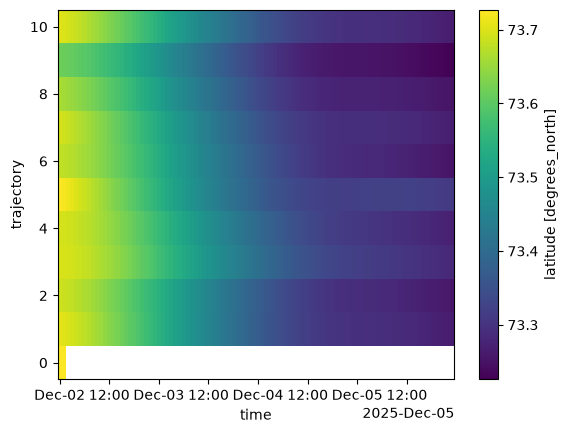

In [11]:
sim.lat.plot()

In [12]:
print([[i,i] for i in range(17)])



[[0, 0], [1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10], [11, 11], [12, 12], [13, 13], [14, 14], [15, 15], [16, 16]]


In [13]:
# sim.y_sea_water_velocity.where(~np.isnan(sim.lat),drop=True).trajectory

In [14]:
# # --- Open all simulation results in one dataset --- 
# with xr.open_mfdataset(
#     file_l,
#     combine="nested",
#     concat_dim="run",
#     parallel=True,
#     engine="netcdf4",
#     # chunks={'time': 10}
# ) as simall: 
#     simall = simall.assign_coords(run=file_l)  # or any list of labels

In [15]:
# # --- find trajectories
# # by seeding length
# seedinglengths = np.nanmax(simall.length[0,:,:],axis=1)
# seedinglengths_unq = np.unique(seedinglengths)
# print(seedinglengths_unq)
# seedinglengths_dict = {v: np.where(seedinglengths == v)[0].tolist() for v in seedinglengths_unq}
# trajs = np.array([seedinglengths_dict[sl] for sl in seedinglengths_unq[2:]]).flatten()

# #by time
# trajs = np.arange(0,10*10+1) #PART1
# print(trajs, simall.sel(trajectory=trajs).time[np.array([0,-1])].values, np.unique(seedinglengths[trajs]))
# traj = False
# # note = 'wave_only_o300length'

In [16]:
# runtrajdict = {#for analysis of part I and II [timestep: 0-10,11-19]
#              'nextsimanfc_glophyanfc_waverys_windglophynrt':np.arange(0,26*10),
#              'nextsimanfc_glophyanfc_mfwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz5_waverys_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz5_mfwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz5_arcmfcwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz6_topaz5_waverys_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt':np.arange(0,20*10),
#             #for analysis of part III
#               # 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':np.arange(20*10,26*10), #2nd
#              'glophyanfc_waverys_windglophynrt':np.arange(20*10,26*10),
#              'topaz5_waverys_windglophynrt':np.arange(20*10,26*10),
#              'topaz6_topaz5_waverys_windglophynrt':np.arange(20*10,26*10),#maybe change ideces here to matchdifferent counting
#             'nextsim':np.arange(20*10,26*10),
# }
# colordict = {#for analysis of part I and II
#              'nextsimanfc_glophyanfc_waverys_windglophynrt':{'col':'orange','alpha':1,'kw':'Glophyanfc'},
#              'nextsimanfc_glophyanfc_mfwam_windglophynrt':{'col':'orange','alpha':0.7,'kw':'Glophyanfc'},
#              'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':{'col':'orange','alpha':0.4,'kw':'Glophyanfc'},
#              'nextsimanfc_topaz5_waverys_windglophynrt':{'col':'cyan','alpha':1,'kw':'TOPAZ5'},
#              'nextsimanfc_topaz5_mfwam_windglophynrt':{'col':'cyan','alpha':0.7,'kw':'TOPAZ5'},
#              'nextsimanfc_topaz5_arcmfcwam_windglophynrt':{'col':'cyan','alpha':0.4,'kw':'TOPAZ5'},
#              'nextsimanfc_topaz6_topaz5_waverys_windglophynrt':{'col':'green','alpha':1,'kw':'TOPAZ6+5'},
#              'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt':{'col':'green','alpha':0.7,'kw':'TOPAZ6+5'},
#              'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt':{'col':'green','alpha':0.4,'kw':'TOPAZ6+5'},
#             #for analysis of part III
#              'nextsim':{'col':'red','alpha':1,'kw':'neXtSIM'},
#              'glophyanfc_waverys_windglophynrt':{'col':'orange','alpha':1,'kw':'Glophyanfc'},
#              'topaz5_waverys_windglophynrt':{'col':'cyan','alpha':1,'kw':'TOPAZ5'},
#              'topaz6_topaz5_waverys_windglophynrt':{'col':'green','alpha':1,'kw':'TOPAZ6+5'},
# }
# legenddict = {              
#             'Simulations with input by: \nneXtSIM':{'col':'red','alpha':1},
#             'Glophyanfc':{'col':'orange','alpha':1},
#               'TOPAZ5':{'col':'cyan','alpha':1},
#               'TOPAZ6+5':{'col':'green','alpha':1},
#               'WAVERYS (alpha=1)':{'col':'green','alpha':1},
#               'MFWAM (alpha=0.7)':{'col':'green','alpha':0.7},
#               'ARCMFCWAM (alpha=0.4)':{'col':'green','alpha':0.4},
#              }

In [17]:
# # Map plot comparing simulations with different input

# #def
# url_letters, note_letters, fileending_letters = 19,8,3
# note = 'all'
# #by = inputdataidx
# # cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
# # col = cmap(np.linspace(0, 1, 20))[::2]#20 colors


# #Figure
# fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
# ax.coastlines(resolution='10m')
# trans = ccrs.PlateCarree()
# #ax.set_extent((-42.5, -11, 65, 78))

# # plot sim
# #version that reads from join simall datset
# # for inputdataidx, inputdataurl in enumerate(simall.run.values):
# #     inputdata = inputdataurl[url_letters:-(note_letters+fileending_letters)]
# #     print(inputdataidx, inputdata,colordict[inputdata])
#     # for traj in runtrajdict[inputdata]:# trajs if traj else simall.trajectory:
#     #     plotcol = colordict['nextsim']['col'] if np.logical_and(inputdata=='nextsimanfc_glophyanfc_waverys_windglophynrt',traj in np.arange(10*20,26*10,1)) else colordict[inputdata]['col']
#     #     ax.plot(simall.lon.sel(run=inputdataurl,trajectory=traj).dropna(dim="time"),simall.lat.sel(run=inputdataurl,trajectory=traj).dropna(dim="time"),
#     #     color= plotcol,
#     #     alpha=colordict[inputdata]['alpha'],#col[inputdataidx],
#     #     linewidth=0.5,
#     #     transform=trans)
#     #version that open up every sim results individually (faster)
# for inputdataidx, inputdata in enumerate(file_l):
#     sim = xr.open_dataset('./results/juliette_%s_wavedir.nc'%(inputdata if inputdata!='nextsim' else 'nextsimanfc_glophyanfc_waverys_windglophynrt'))
#     plot_col = colordict[inputdata]['col']
#     print(inputdataidx, inputdata ,colordict[inputdata])
#     for traj in runtrajdict[inputdata]:
#         # plotcol = colordict['nextsim']['col'] if np.logical_and(inputdata=='nextsimanfc_glophyanfc_waverys_windglophynrt',traj in np.arange(10*20,26*10,1)) else colordict[inputdata]['col']
#         ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
#             color= plot_col,
#             alpha=colordict[inputdata]['alpha'],#col[inputdataidx],
#             linewidth=0.5,
#             transform=trans)

# # plot obs
# ax.plot(obs_3day['lon'],obs_3day['lat'],'>',transform=trans,color='k')
# ax.plot(obs['lon'],obs['lat'],transform=trans,color='k',label='Observation')
# # for d in range(obs_3day['time'].size):
# for d in range(obs_3day.time.size):
#     if d not in [1,2,3,4,5,12,15,16,17,18,19]:
#         ax.text(obs_3day['lon'][d],obs_3day['lat'][d],obs_3day['time'][d].values.astype('datetime64[D]').astype(str),transform=trans,color='k',fontsize=12)

# #legend
# legend_elements = [Line2D([0], [0],linestyle='-', color='k', lw=1,label='Observations'),
#                   Line2D([0], [0],linestyle='-', color='w',marker='>',markerfacecolor='k', lw=1,label='3-daily Positions')]
# # legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color=col[inputdataidx2], lw=1,
# #                                           label=inputdata2[url_letters:-(note_letters+fileending_letters)].replace('_',', ').title() if inputdataidx2>0 else 'Simulations with input by: \n'+inputdata2[19:-3].replace('_',', ').title() )
# #                                           for inputdataidx2,inputdata2 in enumerate(simall.run.values)]
# legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color=legenddict[el]['col'],alpha=legenddict[el]['alpha'], lw=1, label=el) for el in legenddict]
# leg = fig.legend(handles=legend_elements,bbox_to_anchor=(0.15, 0.34),loc='upper left',fontsize=13)#fontsize=fs,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
# plt.axis('off')
# fig.add_artist(leg)
# if note!=False: plt.savefig('./results/analysis_juliette_map_%s.png'%note,dpi=200,transparent=True,bbox_inches='tight')
# plt.show()



In [18]:
# --- Checks on combined dataset of simulations results simall

# # --Check for variables from one "seeding round"
# # simall.length[0,np.arange(60,70),:].dropna(dim='time').shape 

# # --Check for variables at datetime
# simall_t1 = simall.sel(time=datetime(2025,10,18,0), method="nearest") 

# simall_t1_nan = simall_t1.dropna(
#     dim="trajectory",
#     # subset=["sea_surface_wave_from_direction"],
#     subset=["length"],
#     how="any" )
# # print(simall_t1_nan.run) #which runs
# #print (simall_t1_nan.trajectory) #which trajectory numbers
# # simall_t1_nan.sea_surface_wave_from_direction.values
# # simall_t1_nan.sea_surface_wave_significant_height.values
# # simall_t1_nan.sea_surface_wave_stokes_drift_x_velocity.plot()
# # simall_t1_nan.x_sea_water_velocity.values
# simall_t1_nan.sea_ice_area_fraction.plot()

# # simall_t1_nan.draft.values#[:,0].values


In [19]:
# --- Checks on one simulation result file ---

# sim = xr.open_dataset('./results/juliette_topaz6_topaz5_waverys_windglophynrt_wavedir.nc')
# np.sum(np.isnan(sim.x_sea_water_velocity))/sim.x_sea_water_velocity.size
# sim_t1 = sim.sel(time=datetime(2025,10,21,0), method="nearest") 
# sim_t1.sea_surface_wave_from_direction.plot()
# sim.x_sea_water_velocity.plot()
# sim.attrs